In [458]:
# FAZA 1 - UČITAVANJE PODATAKA

import pandas as pd
import numpy as np

# Učitavanje podataka sa GitHub-a
url = "https://raw.githubusercontent.com/jfjelstul/worldcup/master/data-csv/matches.csv"
df = pd.read_csv(url)

df.to_csv('data/raw/matches.csv', index=False)

# Dimenzije skupa
print(f"Broj utakmica (redova): {df.shape[0]}")
print(f"Broj atributa (kolona): {df.shape[1]}")

# Ispis prvih 5 redova tabele
df.head()


Broj utakmica (redova): 1248
Broj atributa (kolona): 37


,key_id,tournament_id,tournament_name,match_id,match_name,stage_name,group_name,group_stage,knockout_stage,replayed,...,away_team_score_margin,extra_time,penalty_shootout,score_penalties,home_team_score_penalties,away_team_score_penalties,result,home_team_win,away_team_win,draw
0,1,WC-1930,1930 FIFA Men's World Cup,M-1930-01,France vs Mexico,group stage,Group 1,1,0,0,...,-3,0,0,0-0,0,0,home team win,1,0,0
1,2,WC-1930,1930 FIFA Men's World Cup,M-1930-02,United States vs Belgium,group stage,Group 4,1,0,0,...,-3,0,0,0-0,0,0,home team win,1,0,0
2,3,WC-1930,1930 FIFA Men's World Cup,M-1930-03,Yugoslavia vs Brazil,group stage,Group 2,1,0,0,...,-1,0,0,0-0,0,0,home team win,1,0,0
3,4,WC-1930,1930 FIFA Men's World Cup,M-1930-04,Romania vs Peru,group stage,Group 3,1,0,0,...,-2,0,0,0-0,0,0,home team win,1,0,0
4,5,WC-1930,1930 FIFA Men's World Cup,M-1930-05,Argentina vs France,group stage,Group 1,1,0,0,...,-1,0,0,0-0,0,0,home team win,1,0,0


Zadržano 5 kolona: (1248, 5)

Nema nedostajućih vrednosti!


  home_team_name away_team_name   stage_name            tournament_name  \
0         France         Mexico  group stage  1930 FIFA Men's World Cup   
1  United States        Belgium  group stage  1930 FIFA Men's World Cup   
2     Yugoslavia         Brazil  group stage  1930 FIFA Men's World Cup   
3        Romania           Peru  group stage  1930 FIFA Men's World Cup   
4      Argentina         France  group stage  1930 FIFA Men's World Cup   

          result  
0  home team win  
1  home team win  
2  home team win  
3  home team win  
4  home team win  

Distribucija ishoda utakmica:
  home team win: 703
  away team win: 335
  draw: 210

Procentualno:
  home team win: 56.33%
  away team win: 26.84%
  draw: 16.83%


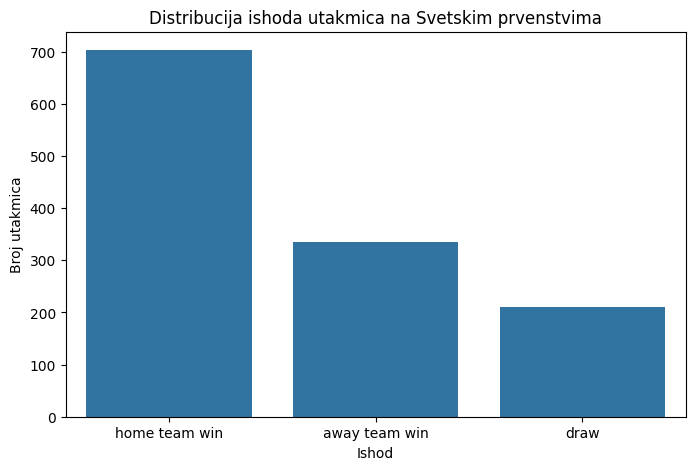

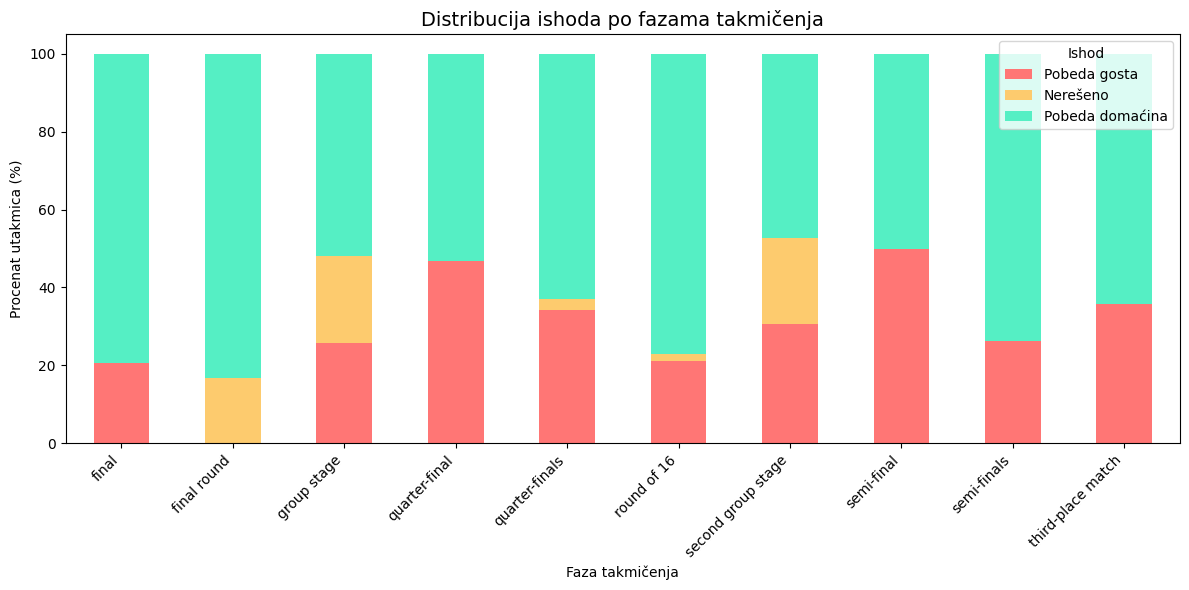

In [459]:
#FAZA 2 - PREPROCESIRANJE PODATAKA

# Uklanjanje nebitnih kolona

# Zadržavamo samo 5 kolona:
# home_team_name, away_team_name - koji timovi igraju
# stage_name - faza takmičenja (grupna/nokaut)
# tournament_name - za izvlačenje godine
# result - ciljna promenljiva
# home_goals, away_goals - poznati tek nakon utakmice
# date, city, stadium, win_conditions, id - nisu relevantni

df_selected = df[[
    'home_team_name',
    'away_team_name',
    'stage_name',
    'tournament_name',
    'result'
]].copy()

print("Zadržano 5 kolona:", df_selected.shape)

# Provera nedostajućih vrednosti
null_counts = df_selected.isnull().sum()
if null_counts.sum() == 0:
    print("\nNema nedostajućih vrednosti!")
else:
    print(null_counts[null_counts > 0])

# Prikaz preostalih kolona
print("\n")
print(df_selected.head())

# Distribucija ciljne promenljive (result)
print("\nDistribucija ishoda utakmica:")

counts = df_selected['result'].value_counts()
for ishod, broj in counts.items():
    print(f"  {ishod}: {broj}")

print("\nProcentualno:")
procenti = df_selected['result'].value_counts(normalize=True) * 100
for ishod, proc in procenti.items():
    print(f"  {ishod}: {proc:.2f}%")

# Vizuelizacija distribucije
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(data=df_selected, x='result', order=df_selected['result'].value_counts().index)
plt.title('Distribucija ishoda utakmica na Svetskim prvenstvima')
plt.xlabel('Ishod')
plt.ylabel('Broj utakmica')
plt.show()

# 1. Distribucija ishoda po fazama takmičenja
plt.figure(figsize=(12, 6))

# Pravimo unakrsnu tabelu
crosstab_stage = pd.crosstab(df_selected['stage_name'], df_selected['result'], normalize='index') * 100

# Stacked bar chart
crosstab_stage.plot(kind='bar', stacked=True, ax=plt.gca(), color=['#ff7675', '#fdcb6e', '#55efc4'])
plt.title('Distribucija ishoda po fazama takmičenja', fontsize=14)
plt.xlabel('Faza takmičenja')
plt.ylabel('Procenat utakmica (%)')
plt.legend(title='Ishod', labels=['Pobeda gosta', 'Nerešeno', 'Pobeda domaćina'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [460]:
#FAZA 3 - FEATURE ENGINEERING

# Učitavanje kolona potrebnih za računanje
df_full = df[['home_team_name', 'away_team_name', 'stage_name',
              'tournament_name', 'result', 'home_team_score', 'away_team_score',
              'match_date']].copy()

# Konvertovanje datuma u datetime format
df_full['match_date'] = pd.to_datetime(df_full['match_date'])

# Izdvajanje godine
df_full['year'] = df_full['tournament_name'].str.extract(r'(\d{4})').astype(int)

# Sortiranje po datumu
df_full = df_full.sort_values('match_date').reset_index(drop=True)

print("Podaci sortirani po datumu!")
print(df_full[['match_date', 'home_team_name', 'away_team_name']].head(10))

# Računanje forme domaćina
def calculate_home_form_with_date(df):
    """Računa prosek golova domaćina u poslednje 3 utakmice PRE ove utakmice"""
    form = []
    for idx, row in df.iterrows():
        team = row['home_team_name']
        current_date = row['match_date']
        current_tournament = row['tournament_name']

        # Pronalazi prethodne utakmice
        prev_matches = df[(df['tournament_name'] == current_tournament) &
                          (df['home_team_name'] == team) &
                          (df['match_date'] < current_date) &
                          (df.index < idx)]
        prev_matches = prev_matches.tail(3)

        if len(prev_matches) == 0:
            form.append(0.0)
        else:
            avg_goals = prev_matches['home_team_score'].mean()
            form.append(avg_goals)
    return form

# Računanje forme gosta
def calculate_away_form_with_date(df):
    """Računa prosek golova gosta u poslednje 3 utakmice PRE ove utakmice"""
    form = []
    for idx, row in df.iterrows():
        team = row['away_team_name']
        current_date = row['match_date']
        current_tournament = row['tournament_name']

        # Pronalazi prethodne utakmice
        prev_matches = df[(df['tournament_name'] == current_tournament) &
                          (df['away_team_name'] == team) &
                          (df['match_date'] < current_date) &
                          (df.index < idx)]
        prev_matches = prev_matches.tail(3)

        if len(prev_matches) == 0:
            form.append(0.0)
        else:
            avg_goals = prev_matches['away_team_score'].mean()
            form.append(avg_goals)
    return form

# Računanje HEAD-TO-HEAD
def calculate_head_to_head_with_date(df):
    """Broji koliko puta je domaćin pobedio u prethodnim susretima (pre ovog datuma)"""
    h2h = []
    for idx, row in df.iterrows():
        home = row['home_team_name']
        away = row['away_team_name']
        current_date = row['match_date']

        # Prethodni susreti istih timova
        prev_meetings = df[((df['home_team_name'] == home) & (df['away_team_name'] == away) |
                            (df['home_team_name'] == away) & (df['away_team_name'] == home)) &
                           (df['match_date'] < current_date)]

        home_wins = 0
        for _, m in prev_meetings.iterrows():
            if m['result'] == 'home team win' and m['home_team_name'] == home:
                home_wins += 1
            elif m['result'] == 'away team win' and m['away_team_name'] == home:
                home_wins += 1
        h2h.append(home_wins)
    return h2h

# Izračunavanje
df_full['home_form'] = calculate_home_form_with_date(df_full)
df_full['away_form'] = calculate_away_form_with_date(df_full)
df_full['head_to_head'] = calculate_head_to_head_with_date(df_full)

# Finalni skup
df_model = df_full[['home_team_name', 'away_team_name', 'stage_name',
                     'year', 'home_form', 'away_form', 'head_to_head', 'result']].copy()

print("\n")
print(f"\nKolone: {df_model.columns.tolist()}")
print(f"Dimenzije: {df_model.shape}")
print("\nPrvih 5 redova:")
print(df_model.head())

# Prikaži utakmice gde je home_form ili away_form veći od 0
forme_vece_od_nule = df_model[(df_model['home_form'] > 0) | (df_model['away_form'] > 0)]
print(f"\nBroj utakmica sa formom > 0: {len(forme_vece_od_nule)}")
print("\nPrimer:")
print(forme_vece_od_nule[['home_team_name', 'away_team_name', 'year', 'home_form', 'away_form']].head(10))

Podaci sortirani po datumu!
  match_date home_team_name away_team_name
0 1930-07-13         France         Mexico
1 1930-07-13  United States        Belgium
2 1930-07-14     Yugoslavia         Brazil
3 1930-07-14        Romania           Peru
4 1930-07-15      Argentina         France
5 1930-07-16          Chile         Mexico
6 1930-07-17     Yugoslavia        Bolivia
7 1930-07-17  United States       Paraguay
8 1930-07-18        Uruguay           Peru
9 1930-07-19      Argentina         Mexico



Kolone: ['home_team_name', 'away_team_name', 'stage_name', 'year', 'home_form', 'away_form', 'head_to_head', 'result']
Dimenzije: (1248, 8)

Prvih 5 redova:
  home_team_name away_team_name   stage_name  year  home_form  away_form  \
0         France         Mexico  group stage  1930        0.0        0.0   
1  United States        Belgium  group stage  1930        0.0        0.0   
2     Yugoslavia         Brazil  group stage  1930        0.0        0.0   
3        Romania           Peru  gr

Provera Elo rejtinga:

Brazil:
   1994: 1775 elo
   2002: 1819 elo
   2010: 1941 elo
   2018: 1994 elo
   2022: 2001 elo

Argentina:
   1994: 1750 elo
   2002: 1844 elo
   2010: 1853 elo
   2018: 1896 elo
   2022: 1951 elo

Germany:
   1994: 1838 elo
   2002: 1781 elo
   2010: 1817 elo
   2018: 1898 elo
   2022: 1861 elo

United States:
   1994: 1519 elo
   2002: 1669 elo
   2010: 1720 elo
   2018: 1737 elo
   2022: 1778 elo

Japan:
   1994: 1605 elo
   2002: 1683 elo
   2010: 1689 elo
   2018: 1698 elo
   2022: 1768 elo

Prijateljskih utakmica: 18388

Sve kolone u df_model:
   1. home_team_name
   2. away_team_name
   3. stage_name
   4. year
   5. head_to_head
   6. result
   7. fifa_rank_diff
   8. home_form_total
   9. away_form_total

Dimenzije df_model: (1248, 9)


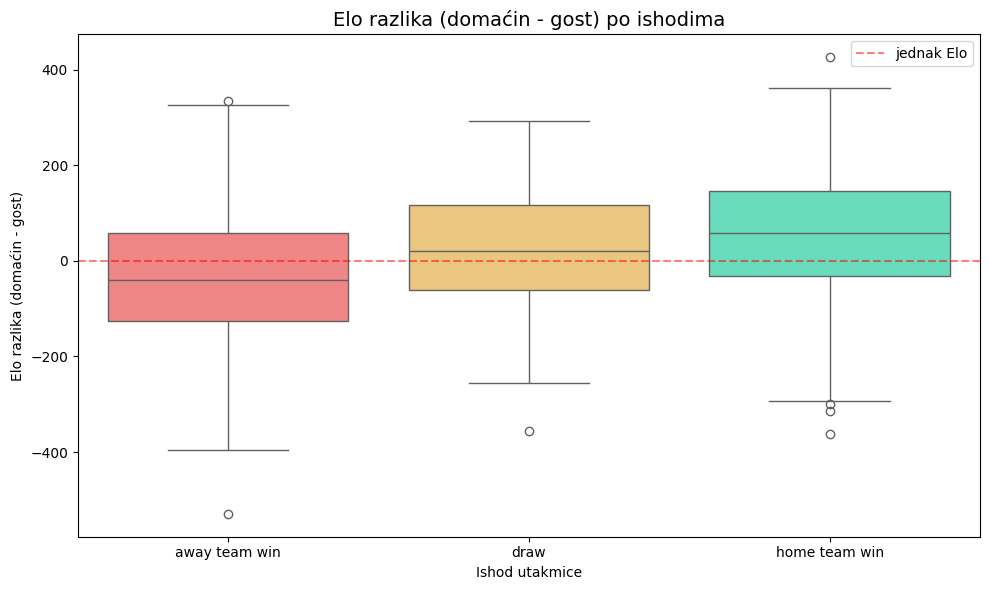

In [461]:
# ELO RANKING (umesto FIFA rankinga) + prijateljske utakmice
# Kolone sadrže Elo rejting, ne zvanični FIFA rang.
# Elo se računa od PRVE utakmice u datasetu (1872) pa nadalje, pa NEMA nula/praznina


import pandas as pd
import numpy as np

df_model['match_date'] = df_full['match_date']

url_results = "https://raw.githubusercontent.com/martj42/international_results/master/results.csv"
df_results = pd.read_csv(url_results)
df_results['date'] = pd.to_datetime(df_results['date'])
df_results = df_results.sort_values('date').reset_index(drop=True)

K = 20           # koliko brzo elo reaguje na rezultate
HOME_ADV = 100   # bonus za domaćina pri računanju očekivanog ishoda

elo = {}          # trenutni elo svakog tima
elo_history = []  

def get_elo(team):
    return elo.get(team, 1500.0)  # 1500 = početni elo za tim koji se prvi put pojavljuje

for row in df_results.itertuples():
    home, away = row.home_team, row.away_team
    home_score, away_score = row.home_score, row.away_score
    date = row.date

    elo_home, elo_away = get_elo(home), get_elo(away)
    expected_home = 1 / (1 + 10 ** ((elo_away - (elo_home + HOME_ADV)) / 400))

    if home_score > away_score:
        actual_home = 1.0
    elif home_score == away_score:
        actual_home = 0.5
    else:
        actual_home = 0.0

    new_elo_home = elo_home + K * (actual_home - expected_home)
    new_elo_away = elo_away + K * ((1 - actual_home) - (1 - expected_home))

    elo[home] = new_elo_home
    elo[away] = new_elo_away

    elo_history.append((home, date, new_elo_home))
    elo_history.append((away, date, new_elo_away))

df_elo = pd.DataFrame(elo_history, columns=['team_name', 'date', 'elo']).sort_values('date')

# Mapiranje imena timova (worldcup dataset vs results.csv se ponekad ne zovu isto)
team_name_map = {
    'South Korea': 'South Korea',
    'IR Iran': 'Iran',
    'United States': 'United States',
}

def map_team(name):
    return team_name_map.get(name, name)

elo_by_team = {team: g for team, g in df_elo.groupby('team_name')}

def get_real_fifa_rank(team_name, match_date):
    mapped = map_team(team_name)
    g = elo_by_team.get(mapped)
    if g is None:
        return 1500.0  # tim se ne pojavljuje u datasetu utakmica - neutralan default
    sub = g[g['date'] < match_date]
    if len(sub) == 0:
        return 1500.0  # nema prethodnih utakmica pre ove
    return sub.iloc[-1]['elo']

df_model['home_fifa_rank'] = df_model.apply(
    lambda row: get_real_fifa_rank(row['home_team_name'], row['match_date']), axis=1
)
df_model['away_fifa_rank'] = df_model.apply(
    lambda row: get_real_fifa_rank(row['away_team_name'], row['match_date']), axis=1
)
df_model['fifa_rank_diff'] = df_model['home_fifa_rank'] - df_model['away_fifa_rank']

print("Provera Elo rejtinga:")
test_teams = ['Brazil', 'Argentina', 'Germany', 'United States', 'Japan']
for team in test_teams:
    print(f"\n{team}:")
    for year, date in [(1994,'1994-06-01'),(2002,'2002-06-01'),(2010,'2010-06-01'),(2018,'2018-06-01'),(2022,'2022-06-01')]:
        r = get_real_fifa_rank(team, pd.Timestamp(date))
        print(f"   {year}: {r:.0f} elo")


# Prijateljska forma
df_friendly = df_results[df_results['tournament'] == 'Friendly'].copy()
print(f"\nPrijateljskih utakmica: {len(df_friendly)}")

team_mapping = {
    'USA': 'United States',
    'United States': 'United States',
    'Korea Republic': 'South Korea',
    'South Korea': 'South Korea',
    'Russia': 'Russia',
    'Germany': 'Germany',
    'IR Iran': 'Iran',
    'Iran': 'Iran',
    'England': 'England',
    'Brazil': 'Brazil',
    'Argentina': 'Argentina',
    'France': 'France',
    'Spain': 'Spain',
    'Mexico': 'Mexico',
    'Netherlands': 'Netherlands',
    'Portugal': 'Portugal',
    'Belgium': 'Belgium',
    'Croatia': 'Croatia',
    'Italy': 'Italy',
    'Uruguay': 'Uruguay',
    'Colombia': 'Colombia',
    'Switzerland': 'Switzerland',
    'Wales': 'Wales',
    'Senegal': 'Senegal',
    'Australia': 'Australia',
    'Japan': 'Japan',
    'Morocco': 'Morocco',
    'Poland': 'Poland',
    'Serbia': 'Serbia',
    'Tunisia': 'Tunisia',
}

def get_friendly_form(team_name, match_date, n_matches=3):
    """Prosečan broj golova u poslednjih n prijateljskih utakmica"""
    mapped_team = team_mapping.get(team_name, team_name)

    home_matches = df_friendly[df_friendly['home_team'] == mapped_team]
    home_matches = home_matches[home_matches['date'] < match_date]
    home_matches = home_matches.copy()
    home_matches['goals'] = home_matches['home_score']

    away_matches = df_friendly[df_friendly['away_team'] == mapped_team]
    away_matches = away_matches[away_matches['date'] < match_date]
    away_matches = away_matches.copy()
    away_matches['goals'] = away_matches['away_score']

    all_matches = pd.concat([home_matches, away_matches])
    all_matches = all_matches.sort_values('date', ascending=False)
    last_matches = all_matches.head(n_matches)

    if len(last_matches) > 0:
        return last_matches['goals'].mean()
    return 0.0

df_model['home_friendly_form'] = df_model.apply(
    lambda row: get_friendly_form(row['home_team_name'], row['match_date']), axis=1
)
df_model['away_friendly_form'] = df_model.apply(
    lambda row: get_friendly_form(row['away_team_name'], row['match_date']), axis=1
)

df_model['home_form_total'] = df_model['home_form'] * 0.7 + df_model['home_friendly_form'] * 0.3
df_model['away_form_total'] = df_model['away_form'] * 0.7 + df_model['away_friendly_form'] * 0.3

columns_to_drop = [
    'match_date',
    'home_form',
    'away_form',
    'home_fifa_rank',
    'away_fifa_rank',
    'home_friendly_form',
    'away_friendly_form'
]

df_model = df_model.drop(columns=[col for col in columns_to_drop if col in df_model.columns])

print("\nSve kolone u df_model:")
for i, col in enumerate(df_model.columns.tolist(), 1):
    print(f"   {i}. {col}")

print(f"\nDimenzije df_model: {df_model.shape}")

# Elo razlika po ishodima
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_model, x='result', y='fifa_rank_diff', 
            order=['away team win', 'draw', 'home team win'],
            palette=['#ff7675', '#fdcb6e', '#55efc4'])

plt.title('Elo razlika (domaćin - gost) po ishodima', fontsize=14)
plt.xlabel('Ishod utakmice')
plt.ylabel('Elo razlika (domaćin - gost)')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='jednak Elo')
plt.legend()
plt.tight_layout()
plt.show()

In [462]:
#FAZA 4 - ENKODIRANJE KATEGORIJSKIH ATRIBUTA

from sklearn.preprocessing import LabelEncoder

df_encoded = df_model.copy()

# Label encoding za stage_name
stage_order = ['group stage',        'semi-finals',              'final',
        'round of 16',     'quarter-finals',  'third-place match',
        'final round', 'second group stage',      'quarter-final',
         'semi-final']
stage_mapping = {stage: i for i, stage in enumerate(stage_order)}
df_encoded['stage_encoded'] = df_encoded['stage_name'].map(stage_mapping)

# Label encoding za timove
le_home = LabelEncoder()
le_away = LabelEncoder()

df_encoded['home_team_encoded'] = le_home.fit_transform(df_encoded['home_team_name'])
df_encoded['away_team_encoded'] = le_away.fit_transform(df_encoded['away_team_name'])

# Uklanjamo originalne tekstualne kolone
df_final = df_encoded.drop(columns=['home_team_name', 'away_team_name', 'stage_name'])

df_final.to_csv('data/processed/df_final.csv', index=False)

print("Kolone nakon enkodiranja:")
print(df_final.columns.tolist())
print("\nPrvih 5 redova:")
print(df_final.head())

# Provera da li je nešto null
null_counts = df_final.isnull().sum()
if null_counts.sum() == 0:
    print("\nNema nedostajućih vrednosti!")
else:
    print(null_counts[null_counts > 0])


Kolone nakon enkodiranja:
['year', 'head_to_head', 'result', 'fifa_rank_diff', 'home_form_total', 'away_form_total', 'stage_encoded', 'home_team_encoded', 'away_team_encoded']

Prvih 5 redova:
   year  head_to_head         result  fifa_rank_diff  home_form_total  \
0  1930             0  home team win     -145.335175              0.4   
1  1930             0  home team win       54.525277              1.5   
2  1930             0  home team win      -40.889329              1.0   
3  1930             0  home team win       18.605136              0.6   
4  1930             0  home team win      265.028332              0.3   

   away_form_total  stage_encoded  home_team_encoded  away_team_encoded  
0              0.7              0                 27                 45  
1              0.6              0                 78                  5  
2              0.7              0                 82                  8  
3              0.0              0                 56                 55 

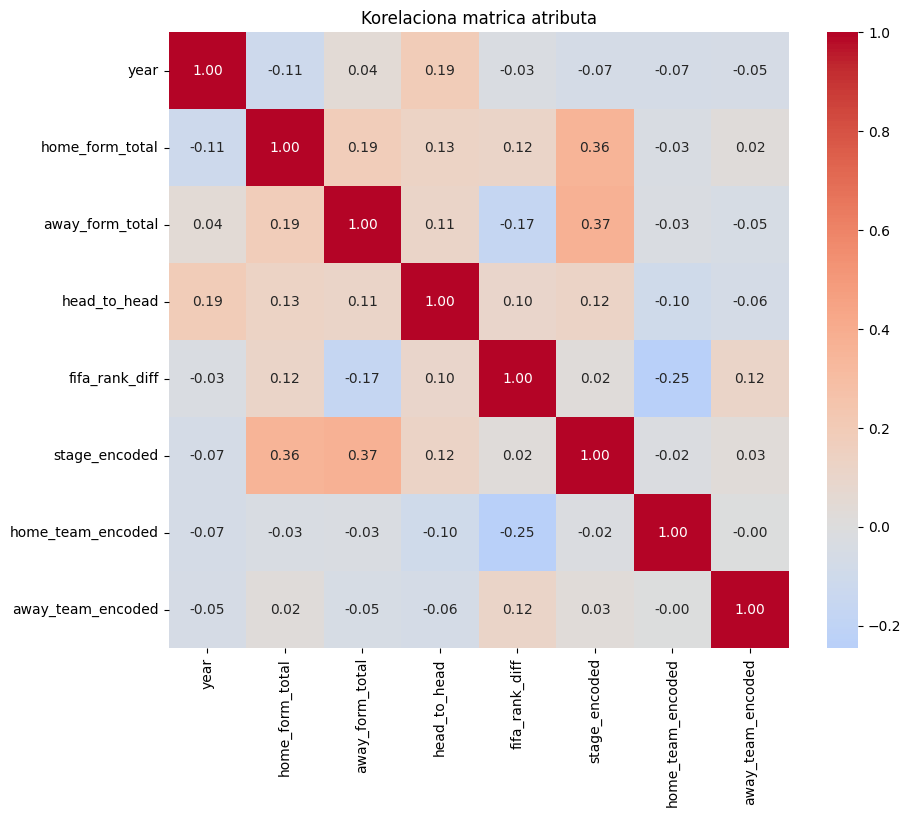

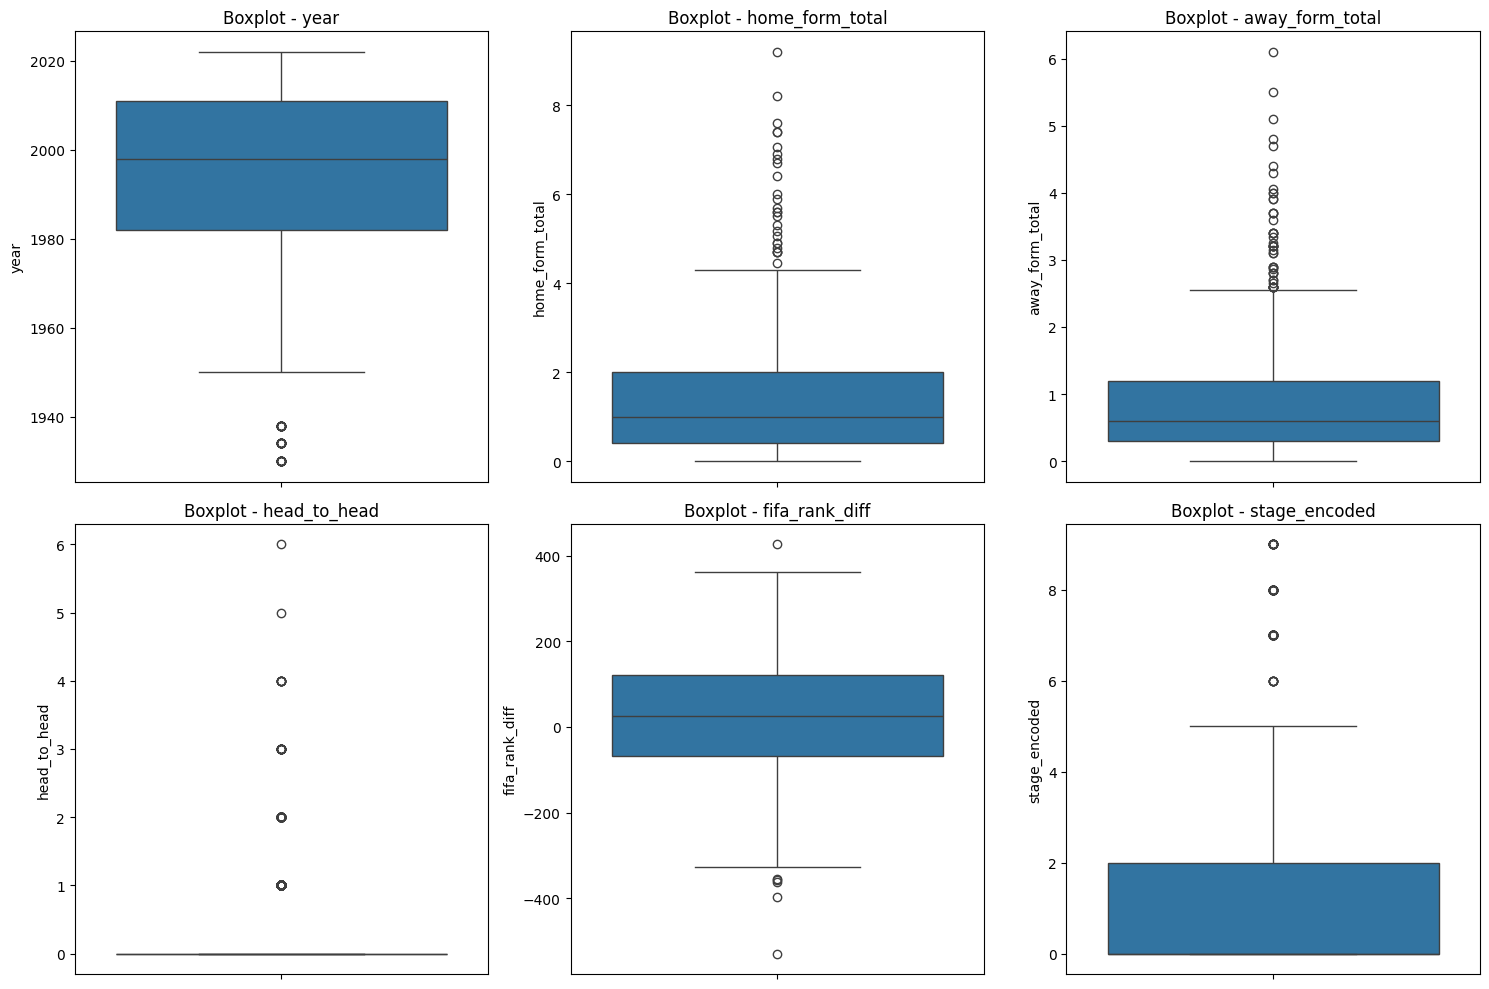

fifa_rank_diff: 6 outlier-a
home_form_total: 26 outlier-a
away_form_total: 47 outlier-a
head_to_head: 307 outlier-a


In [463]:
# FAZA 5 - EDA
# Korelaciona matrica numeričkih atributa
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = ['year', 'home_form_total', 'away_form_total', 'head_to_head', 
                'fifa_rank_diff', 'stage_encoded', 'home_team_encoded', 'away_team_encoded']

plt.figure(figsize=(10, 8))
sns.heatmap(df_final[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Korelaciona matrica atributa')
plt.show()

# Outlier analiza
import seaborn as sns
import matplotlib.pyplot as plt


# Boxplot za glavne atribute 
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

features = ['year', 'home_form_total', 'away_form_total', 'head_to_head', 
            'fifa_rank_diff', 'stage_encoded']

for i, feat in enumerate(features):
    sns.boxplot(y=df_final[feat], ax=axes[i])
    axes[i].set_title(f'Boxplot - {feat}')

plt.tight_layout()
plt.show()

# IQR metoda

for feat in ['fifa_rank_diff', 'home_form_total', 'away_form_total', 'head_to_head']:
    Q1 = df_final[feat].quantile(0.25)
    Q3 = df_final[feat].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df_final[(df_final[feat] < lower) | (df_final[feat] > upper)]
    print(f"{feat}: {len(outliers)} outlier-a")



In [464]:
# FAZA 6 - PRIPREMA ZA TRENING

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Enkodiranje ciljne promenljive
le_result = LabelEncoder()
df_final['result_encoded'] = le_result.fit_transform(df_final['result'])

print("Mapiranje rezultata:")
for i, klasa in enumerate(le_result.classes_):
    print(f"  {klasa} -> {i}")

X = df_final.drop(['result', 'result_encoded'], axis=1)
y = df_final['result_encoded']

# Podela na trening i test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nUkupno utakmica: {len(df_final)}")
print(f"Trening skup (80%): {len(X_train)} utakmica")
print(f"Test skup (20%): {len(X_test)} utakmica")

# Skaliranje
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nPre skaliranja - mean: {X_train.mean().mean():.3f}")
print(f"Pre skaliranja - std:  {X_train.std().mean():.3f}")
print(f"Nakon skaliranja - mean: {X_train_scaled.mean():.3f}")
print(f"Nakon skaliranja - std:  {X_train_scaled.std():.3f}")

Mapiranje rezultata:
  away team win -> 0
  draw -> 1
  home team win -> 2

Ukupno utakmica: 1248
Trening skup (80%): 998 utakmica
Test skup (20%): 250 utakmica

Pre skaliranja - mean: 262.820
Pre skaliranja - std:  26.973
Nakon skaliranja - mean: -0.000
Nakon skaliranja - std:  1.000


In [465]:
# FAZA 7 - TRENING MODELA

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

if isinstance(y_train.iloc[0], str):
    y_train_encoded = le_result.transform(y_train)
    y_test_encoded = le_result.transform(y_test)
else:
    y_train_encoded = y_train
    y_test_encoded = y_test

# Modeli
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, eval_metric='mlogloss', random_state=42)
}

results = []
best_model = None
best_accuracy = 0

for name, model in models.items():
    model.fit(X_train_scaled, y_train_encoded)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test_encoded, y_pred)
    results.append((name, acc))
    
    if acc > best_accuracy:
        best_accuracy = acc
        best_model = name

print(f"{'Model':<20} {'Tačnost':<10}")

for name, acc in results:
    print(f"{name:<20} {acc:.2%}")

print(f"Najbolji model: {best_model}")
print(f"Tačnost: {best_accuracy:.2%}")

Model                Tačnost   
Logistic Regression  62.00%
Decision Tree        52.40%
Random Forest        61.20%
XGBoost              57.60%
Najbolji model: Logistic Regression
Tačnost: 62.00%


In [466]:
# Tabela metrika za sve modele
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

models = [logreg, dt, rf, xgb]
names = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']

results = []

for name, model in zip(names, models):
    y_pred = model.predict(X_test_scaled)
    report = classification_report(y_test, y_pred, target_names=['away_win', 'draw', 'home_win'], output_dict=True)
    
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Draw Precision': report['draw']['precision'],
        'Draw Recall': report['draw']['recall'],
        'Draw F1': report['draw']['f1-score'],
        'Home Recall': report['home_win']['recall'],
        'Away Recall': report['away_win']['recall']
    })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

              Model  Accuracy  Draw Precision  Draw Recall  Draw F1  Home Recall  Away Recall
Logistic Regression     0.620        0.000000     0.000000 0.000000     0.886525     0.447761
      Decision Tree     0.524        0.250000     0.238095 0.243902     0.659574     0.417910
      Random Forest     0.568        0.287671     0.500000 0.365217     0.595745     0.552239
            XGBoost     0.604        0.416667     0.119048 0.185185     0.829787     0.432836


In [467]:
# FAZA 8 - HIPERPARAMETRI I FAZA 9 - ANALIZA REZULTATA
# Grid search za Logistic Regression
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear'],
    'class_weight': [
        {0: 1.0, 1: 1.0, 2: 1.0},
        {0: 1.0, 1: 1.5, 2: 1.0},
        {0: 1.0, 1: 2.0, 2: 1.0},
        {0: 1.0, 1: 2.5, 2: 1.0},
        {0: 1.0, 1: 3.0, 2: 1.0}
    ]
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=42),
    param_grid_lr,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_lr.fit(X_train_scaled, y_train)

print(f"Najbolji parametri: {grid_lr.best_params_}")
print(f"Najbolja CV tačnost: {grid_lr.best_score_:.2%}")

y_pred_lr = grid_lr.predict(X_test_scaled)
acc_lr = accuracy_score(y_test, y_pred_lr)
report_lr = classification_report(y_test, y_pred_lr, output_dict=True)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['away_win', 'draw', 'home_win']))

Najbolji parametri: {'C': 0.01, 'class_weight': {0: 1.0, 1: 1.5, 2: 1.0}, 'solver': 'lbfgs'}
Najbolja CV tačnost: 60.82%

Classification Report:
              precision    recall  f1-score   support

    away_win       0.75      0.36      0.48        67
        draw       0.00      0.00      0.00        42
    home_win       0.61      0.95      0.75       141

    accuracy                           0.63       250
   macro avg       0.45      0.44      0.41       250
weighted avg       0.55      0.63      0.55       250



In [468]:
# Logistic Regression - najbolji balans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lr_final = LogisticRegression(
    C=0.01,
    solver='lbfgs',
    max_iter=2000,
    random_state=42,
    class_weight={0: 1.0, 1: 2.0, 2: 1.0}
)
lr_final.fit(X_train_scaled, y_train)
y_pred_lr = lr_final.predict(X_test_scaled)

acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Accuracy: {acc_lr:.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['away_win', 'draw', 'home_win']))

Accuracy: 60.40%

Classification Report:
              precision    recall  f1-score   support

    away_win       0.77      0.30      0.43        67
        draw       0.24      0.12      0.16        42
    home_win       0.62      0.89      0.73       141

    accuracy                           0.60       250
   macro avg       0.54      0.44      0.44       250
weighted avg       0.60      0.60      0.56       250



In [469]:
# Grid Search za XGBoost
from sklearn.model_selection import GridSearchCV


param_grid = {
    'max_depth': [2, 3, 4],
    'learning_rate': [0.03, 0.05, 0.1],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 1.0]
}

xgb_grid = XGBClassifier(
    colsample_bytree=0.8,
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=42,
    use_label_encoder=False
)

grid_search = GridSearchCV(
    xgb_grid,
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train, sample_weight=weights)

print(f"Najbolji parametri: {grid_search.best_params_}")
print(f"Najbolja CV tačnost: {grid_search.best_score_:.2%}")

y_pred_grid = grid_search.predict(X_test_scaled)
acc_grid = accuracy_score(y_test, y_pred_grid)
report_grid = classification_report(y_test, y_pred_grid, target_names=['away_win', 'draw', 'home_win'], output_dict=True)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_grid, target_names=['away_win', 'draw', 'home_win']))

Najbolji parametri: {'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
Najbolja CV tačnost: 52.66%

Classification Report:
              precision    recall  f1-score   support

    away_win       0.51      0.54      0.52        67
        draw       0.33      0.50      0.40        42
    home_win       0.72      0.59      0.65       141

    accuracy                           0.56       250
   macro avg       0.52      0.54      0.52       250
weighted avg       0.60      0.56      0.57       250



In [470]:
# Grid Search - Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

param_grid_rf = {
    'n_estimators': [100, 150, 200],
    'max_depth': [8, 10, 12, None],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced', None]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_rf.fit(X_train_scaled, y_train)

for param, value in grid_rf.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nNajbolja CV f1_macro: {grid_rf.best_score_:.4f}")

# Finalni model
best_rf = grid_rf.best_estimator_
y_pred = best_rf.predict(X_test_scaled)

# Metrike
acc = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=['away_win', 'draw', 'home_win'])

print(f"Accuracy: {acc:.2%}")

print("\nClassification Report:")
print(report)

  class_weight: balanced
  max_depth: 8
  min_samples_split: 5
  n_estimators: 100

Najbolja CV f1_macro: 0.5120
Accuracy: 57.20%

Classification Report:
              precision    recall  f1-score   support

    away_win       0.54      0.55      0.54        67
        draw       0.32      0.55      0.41        42
    home_win       0.75      0.59      0.66       141

    accuracy                           0.57       250
   macro avg       0.54      0.56      0.54       250
weighted avg       0.62      0.57      0.59       250



Accuracy: 61.20%

Classification Report:
              precision    recall  f1-score   support

    away_win       0.54      0.57      0.55        67
        draw       0.35      0.40      0.38        42
    home_win       0.74      0.70      0.72       141

    accuracy                           0.61       250
   macro avg       0.55      0.56      0.55       250
weighted avg       0.62      0.61      0.62       250



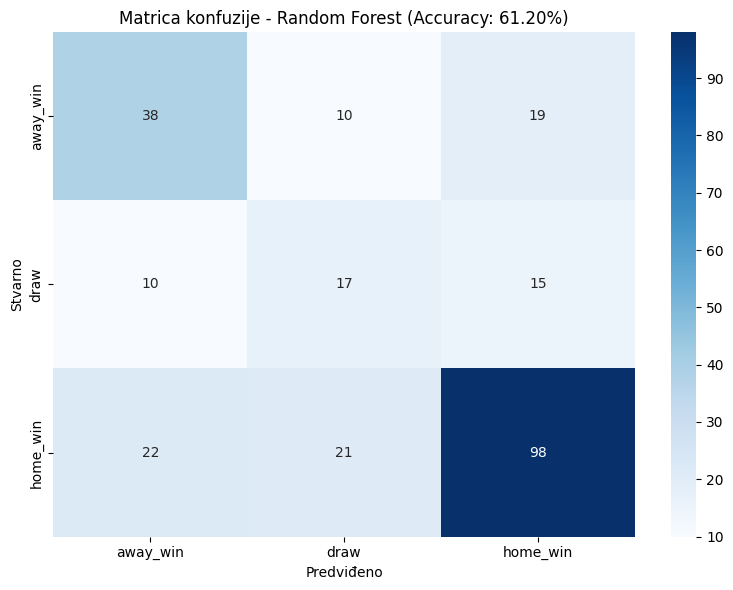


Classification Report:
              precision    recall  f1-score   support

    away_win       0.54      0.57      0.55        67
        draw       0.35      0.40      0.38        42
    home_win       0.74      0.70      0.72       141

    accuracy                           0.61       250
   macro avg       0.55      0.56      0.55       250
weighted avg       0.62      0.61      0.62       250



In [471]:
# Najbolji model - Random Forest (n=150, depth=12, min_samples=2, balanced)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

final_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    min_samples_split=2,
    class_weight='balanced',
    random_state=42
)
final_model.fit(X_train_scaled, y_train)

y_pred_final = final_model.predict(X_test_scaled)

# Metrike
acc_final = accuracy_score(y_test, y_pred_final)
report = classification_report(y_test, y_pred_final, target_names=['away_win', 'draw', 'home_win'])
report_dict = classification_report(y_test, y_pred_final, target_names=['away_win', 'draw', 'home_win'], output_dict=True)

print(f"Accuracy: {acc_final:.2%}")
print("\nClassification Report:")
print(report)

# Matrica konfuzije
cm_final = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues',
            xticklabels=['away_win', 'draw', 'home_win'],
            yticklabels=['away_win', 'draw', 'home_win'])
plt.title(f'Matrica konfuzije - Random Forest (Accuracy: {acc_final:.2%})')
plt.ylabel('Stvarno')
plt.xlabel('Predviđeno')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final, target_names=['away_win', 'draw', 'home_win']))



fifa_rank_diff            0.1929
year                      0.1651
home_form_total           0.1459
away_form_total           0.1370
away_team_encoded         0.1330
home_team_encoded         0.1252
stage_encoded             0.0681
head_to_head              0.0328


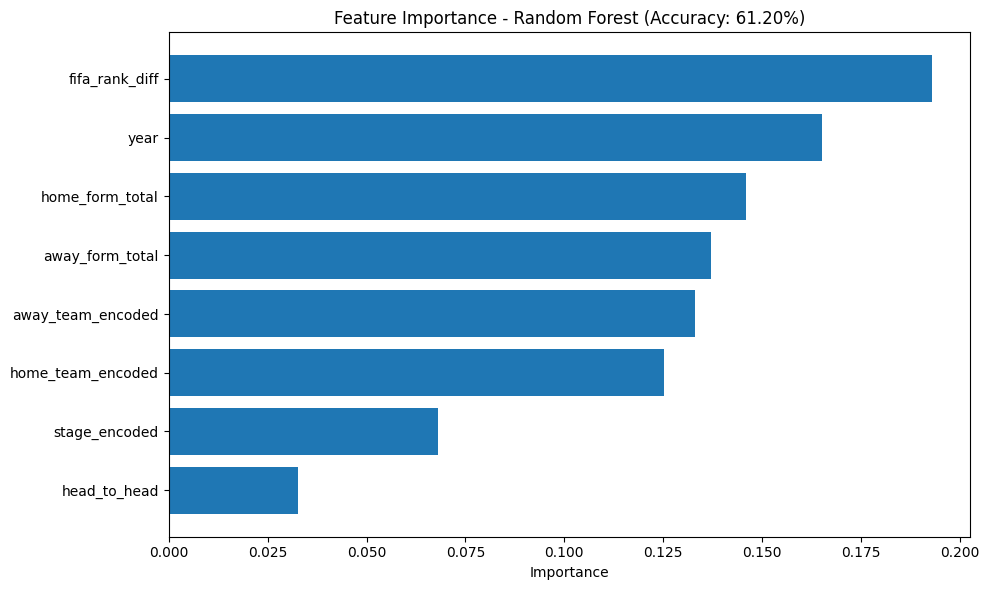

In [472]:
# FAZA 10 - FEATURE IMPORTANCE

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

importances = final_model.feature_importances_
feature_names = X.columns.tolist()

imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

for i, row in imp_df.iterrows():
    print(f"{row['Feature']:25} {row['Importance']:.4f}")

# Grafik
plt.figure(figsize=(10, 6))
plt.barh(imp_df['Feature'], imp_df['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance - Random Forest (Accuracy: 61.20%)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [473]:
# FAZA 11 - TRENING SA TOP 5 ATRIBUTA

top_5 = ['fifa_rank_diff', 'year', 'home_form_total', 'away_form_total', 'away_team_encoded']

X_train_top5 = X_train[top_5]
X_test_top5 = X_test[top_5]

# Skaliranje
scaler_top5 = StandardScaler()
X_train_top5_scaled = scaler_top5.fit_transform(X_train_top5)
X_test_top5_scaled = scaler_top5.transform(X_test_top5)

rf_top5 = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    min_samples_split=2,
    class_weight='balanced',
    random_state=42
)
rf_top5.fit(X_train_top5_scaled, y_train)
y_pred_top5 = rf_top5.predict(X_test_top5_scaled)

acc_top5 = accuracy_score(y_test, y_pred_top5)
report_top5 = classification_report(y_test, y_pred_top5, target_names=['away_win', 'draw', 'home_win'], output_dict=True)

print(f"Accuracy: {acc_top5:.2%}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_top5, target_names=['away_win', 'draw', 'home_win']))

Accuracy: 56.00%

Classification Report:
              precision    recall  f1-score   support

    away_win       0.49      0.52      0.51        67
        draw       0.30      0.40      0.34        42
    home_win       0.72      0.62      0.67       141

    accuracy                           0.56       250
   macro avg       0.50      0.52      0.51       250
weighted avg       0.59      0.56      0.57       250



In [474]:
# FAZA 12 - EKSPORTOVANJE MODELA

import joblib

final_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    min_samples_split=2,
    class_weight='balanced',
    random_state=42
)
final_model.fit(X_train_scaled, y_train)

joblib.dump(final_model, 'models/final_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(le_result, 'models/label_encoder.pkl')

['models/label_encoder.pkl']

In [475]:
joblib.dump(le_home, 'models/le_home.pkl')
joblib.dump(le_away, 'models/le_away.pkl')

['models/le_away.pkl']